In [1]:
# generating Minimum Snap trajectories as a benchmark for the G&CNets
import matplotlib.pyplot as plt
import numpy as np
from sympy import *

# RACE TRACK
# waypoint: [x, y, z, yaw]
waypoints = np.array([
    [1.5, -7., 0.0, np.pi/2],       # start (hover)
]+[
    [1.5, -5., -1.5, np.pi/2],
    [1.5,  5., -1.5, np.pi/2],
    [0.0, 6.5, -1.5, np.pi],
    [-1.5, 5., -1.5, -np.pi/2],
    [-1.5, -5., -1.5,-np.pi/2],
    [0.0, -6.5, -1.5, 0.0],
]*4+[
    [1.5, -7., 0.0, np.pi/2]        # end (hover)
])
waypoints[0,3] = np.pi/2
for i in range(4):
    waypoints[i*6+1,3] = np.pi*0.5+i*2*np.pi
    waypoints[i*6+2,3] = np.pi*0.5+i*2*np.pi
    waypoints[i*6+3,3] = np.pi*1.0+i*2*np.pi
    waypoints[i*6+4,3] = np.pi*1.5+i*2*np.pi
    waypoints[i*6+5,3] = np.pi*1.5+i*2*np.pi
    waypoints[i*6+6,3] = np.pi*2.0+i*2*np.pi
waypoints[-1,3] = waypoints[-2,3]+np.pi/2

region = np.array([
    [-20, 20],  # xmin, xmax
    [-20, 20],  # ymin, ymax
    [-20, 0]   # zmin, zmax
])
    

# Position and yaw are described by nth order polynomials
t = Symbol('t')

# Degree of polynomials
n=6

# number of trajectories
n_traj = len(waypoints)-1

parameters = [Matrix([['p'+str(i)+str(j)+str(k) for j in range(n+1)] for k in range(4)]) for i in range(n_traj)]
T = [Symbol('T'+str(i)) for i in range(n_traj)]

def get_traj(idx):
    P = parameters[idx]
    x   = sum([P[0,i]*t**i for i in range(n+1)])
    y   = sum([P[1,i]*t**i for i in range(n+1)])
    z   = sum([P[2,i]*t**i for i in range(n+1)])
    psi = sum([P[3,i]*t**i for i in range(n+1)])
    return x,y,z,psi

In [2]:
# Objective function
kr = 4
kpsi = 2

# pos and yaw have equal weight
mur = 1
mupsi = 1

def get_Obj(idx):
    x,y,z,psi = get_traj(idx)
    return integrate(mur*(diff(x,t,kr)**2+diff(y,t,kr)**2+diff(z,t,kr)**2) + mupsi*(diff(psi,t,kpsi)**2), (t, 0, T[idx]))

Obj = sum(get_Obj(i) for i in range(n_traj))

In [3]:
# Get constraints of the ith trajectory
def get_constraints(idx):
    x,y,z,psi = get_traj(idx)
    
    # Equality constraints g(p) = 0
    g=[]
    
    # START POINT CONSTRAINTS
    if idx==0:
        # Initial state 
        g.append(x.subs(t,0)-waypoints[0][0])
        g.append(y.subs(t,0)-waypoints[0][1])
        g.append(z.subs(t,0)-waypoints[0][2])
        g.append(psi.subs(t,0)-waypoints[0][3])
        # (hover)
        for i in range(1, 3):
            g.append(diff(x,t,i).subs(t,0))
            g.append(diff(y,t,i).subs(t,0))
            g.append(diff(z,t,i).subs(t,0))
            g.append(diff(psi,t,i).subs(t,0))
    else:
        # Enforce continuity of the first kr derivatives of rT and first kψ derivatives of ψT
        x_,y_,z_,psi_ = get_traj(idx-1)
        for i in range(kr+1):
            g.append(diff(x_,t,i).subs(t,T[idx-1])-diff(x,t,i).subs(t,0))
            g.append(diff(y_,t,i).subs(t,T[idx-1])-diff(y,t,i).subs(t,0))
            g.append(diff(z_,t,i).subs(t,T[idx-1])-diff(z,t,i).subs(t,0))
        for i in range(kpsi+1):
            g.append(diff(psi_,t,i).subs(t,T[idx-1])-diff(psi,t,i).subs(t,0))
    
    # END POINT CONSTRAINTS
    g.append(x.subs(t,T[idx])-waypoints[idx+1][0])
    g.append(y.subs(t,T[idx])-waypoints[idx+1][1])
    g.append(z.subs(t,T[idx])-waypoints[idx+1][2])
    g.append(psi.subs(t,T[idx])-waypoints[idx+1][3])

    if idx == n_traj-1:
        # end point hover
        for i in range(1, 3):
            g.append(diff(x,t,i).subs(t,T[idx]))
            g.append(diff(y,t,i).subs(t,T[idx]))
            g.append(diff(z,t,i).subs(t,T[idx]))
            g.append(diff(psi,t,i).subs(t,T[idx]))
    else:
        # velocity must align with yaw
        psi = waypoints[idx+1][3]
        g.append(sin(psi)*diff(x,t).subs(t,T[idx])-cos(psi)*diff(y,t).subs(t,T[idx]))
        g.append(diff(z,t).subs(t,T[idx]))
        
    # Region constraints
    # add constraints to keep the trajectory within the region
    # we now implement it such that xmin < x(T/2) < xmax, ymin < y(T/2) < ymax, zmin < z(T/2) < zmax
    return g

In [4]:
from amplpy import AMPL

ampl = AMPL()
ampl.eval('option solver snopt;')

ampl.eval('param Tn default '+ str(n_traj) + ';')

# VARIABLES
for t_ in T:
    ampl.eval('var ' + str(t_) + ', >= 0;')
for P in parameters:
    for p in P:
        ampl.eval('var ' + str(p) + ';')

# OBJECTIVE
objective = str(Obj)
objective = objective.replace('**','^')
ampl.eval('minimize myobjective: '+str(objective) +';')

# CONSTRAINTS
ampl.eval('subject to time_constraint: '+str(sum(T))+'=Tn;')

for idx in range(n_traj):
    ampl.eval('subject to time_constraint' + str(idx) + ':' + str(T[idx]) + '= 1.;')

# ADD CONSTRAINTS FOR EACH TRAJ
for idx in range(n_traj):
    g = get_constraints(idx)
    for i in range(len(g)):
        constraint = str(g[i])
        constraint = constraint.replace('**','^')
        ampl.eval('subject to constraint' + str(idx) + '_' + str(i) + ':' + str(constraint) + '=0;')

# SOLVE
ampl.solve()
    
# REMOVE TIME CONSTRIANTS
for idx in range(n_traj):
    ampl.getConstraint('time_constraint'+str(idx)).drop()

# SOLVE
ampl.solve()

SNOPT 7.2-4 SNOPT 7.2-4 : Optimal solution found.
609 iterations, objective 416129.6771
SNOPT 7.2-4 SNOPT 7.2-4 : Optimal solution found.
357 iterations, objective 77365.7219
Nonlin evals: obj = 182, grad = 181, constrs = 182, Jac = 181.


In [5]:
# SOLVE AGAIN?
ampl.solve()

SNOPT 7.2-4 SNOPT 7.2-4 : Optimal solution found.
111 iterations, objective 77365.72193
Nonlin evals: obj = 3, grad = 2, constrs = 3, Jac = 2.


In [6]:
def get_traj_solved(idx):
    x,y,z,psi = get_traj(idx)
    x   = x.subs([(str(p), ampl.getVariable(str(p)).value()) for p in parameters[idx]])
    y   = y.subs([(str(p), ampl.getVariable(str(p)).value()) for p in parameters[idx]])
    z   = z.subs([(str(p), ampl.getVariable(str(p)).value()) for p in parameters[idx]])
    psi = psi.subs([(str(p), ampl.getVariable(str(p)).value()) for p in parameters[idx]])
    return x,y,z,psi

In [7]:
x,y,z,psi =[],[],[],[]
T_ = np.cumsum([0] + [ampl.getVariable(str(T[i])).value() for i in range(n_traj)])
for i in range(n_traj):
    xi,yi,zi,psii = get_traj_solved(i)
    x.append((xi.subs(t,t-T_[i], evaluate=False),(t>=T_[i])&(t<T_[i+1])))
    y.append((yi.subs(t,t-T_[i], evaluate=False),(t>=T_[i])&(t<T_[i+1])))
    z.append((zi.subs(t,t-T_[i], evaluate=False),(t>=T_[i])&(t<T_[i+1])))
    psi.append((psii.subs(t,t-T_[i], evaluate=False),(t>=T_[i])&(t<T_[i+1])))

for xi in x:
    print(xi)
x.append((waypoints[-1][0], True))
y.append((waypoints[-1][1], True))
z.append((waypoints[-1][2], True))
psi.append((waypoints[-1][3], True))

x   = Piecewise(*x, evaluate=False)
y   = Piecewise(*y, evaluate=False)
z   = Piecewise(*z, evaluate=False)
psi = Piecewise(*psi, evaluate=False)
print(T_)

(0.220720563280596*t**6 - 1.19404113431946*t**5 + 2.13012606609781*t**4 - 1.25556360770396*t**3 + 1.5, (t >= 0.0) & (t < 1.61677279080816))
(-5.81260698954838e-15*t + 1.75633783750388*(0.618516099284513*t - 1)**6 - 8.17610983095912*(0.618516099284513*t - 1)**5 + 7.73441989551954*(0.618516099284513*t - 1)**4 - 0.149945471403296*(0.618516099284513*t - 1)**3 - 1.36404271828852*(0.618516099284513*t - 1)**2 + 1.50000000000001, (t >= 1.61677279080816) & (t < 2.92950420950868))
(1.92132158186091e-15*t - 1158.18820405279*(0.341354689559472*t - 1)**6 + 970.953321195711*(0.341354689559472*t - 1)**5 - 87.2049766151243*(0.341354689559472*t - 1)**4 - 60.2565639741033*(0.341354689559472*t - 1)**3 - 11.3286283345255*(0.341354689559472*t - 1)**2 + 1.49999999999999, (t >= 2.92950420950868) & (t < 3.7117315218595))
(-3.52715963066877*t + 1831.46660527515*(0.269416037800875*t - 1)**6 - 1387.68385162886*(0.269416037800875*t - 1)**5 - 76.1491398124985*(0.269416037800875*t - 1)**4 + 199.09960593371*(0.26941

In [8]:
import matplotlib as mpl
import matplotlib.cm as cm

norm = mpl.colors.Normalize(0,20)
cmap = cm.jet 

def color_plot(x_axis,y_axis,color_axis,step=1):
    for i in reversed(range(step,len(x_axis),step)):
        ax = plt.gca()
        ax.plot([x_axis[i-step], x_axis[i]],[y_axis[i-step], y_axis[i]], color=cmap(norm(color_axis[i])))
        ax.axis('equal')
        
def color_plot3D(x_axis,y_axis,z_axis,color_axis,step=1):
    ax = plt.axes(projection='3d')
    for i in reversed(range(step,len(x_axis),step)):
        ax.plot3D([x_axis[i-step], x_axis[i]],[y_axis[i-step], y_axis[i]],[z_axis[i-step], z_axis[i]], color=cmap(norm(color_axis[i])))
#         ax.axis('equal')

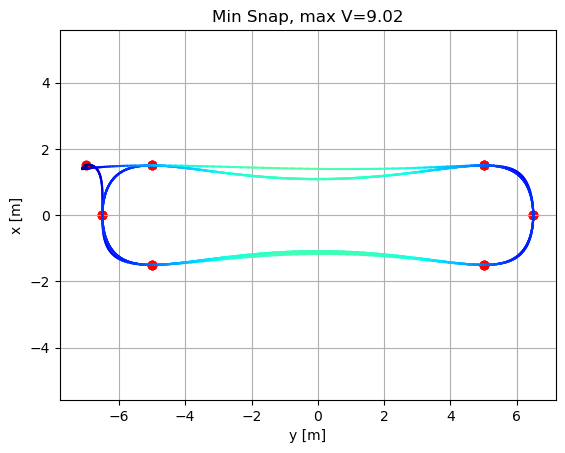

In [9]:
vx = diff(x,t)
vy = diff(y,t)
V = sqrt(vx**2+vy**2)

t_ = np.linspace(0,T_[-1],1000)
x_ = lambdify(t,x)
y_ = lambdify(t,y)
z_ = lambdify(t,z)
psi_ = lambdify(t,psi)
V_ = lambdify(t,V)

color_plot(y_(t_),x_(t_),V_(t_))
plt.scatter(waypoints[:,1],waypoints[:,0],color='red')
plt.xlabel('y [m]')
plt.ylabel('x [m]')
plt.grid()
plt.gca().axis('equal')
Vmax = str(np.round(float(np.max(V_(t_))),2))
plt.title('Min Snap, max V='+Vmax)
plt.show()

In [10]:
# z=simplify(z)
# psi=simplify(psi)

## Generate C code

In [31]:
from sympy.utilities.codegen import codegen

# TRANSFORM TO CYBERZOO COORDINATES
x_ = x
y_ = y
z_ = z
psi_ = psi

psi_dot_ = diff(psi_,t)

vx_ = diff(x_,t)
vy_ = diff(y_,t)
vz_ = diff(z_,t)

ax_ = diff(vx_,t)
ay_ = diff(vy_,t)
az_ = diff(vz_,t)

jx_ = diff(ax_,t)
jy_ = diff(ay_,t)
jz_ = diff(az_,t)



print('generating code')
[(c_name, c_code), (h_name, c_header)] = codegen([
    ("get_x", x_),
    ("get_y", y_),
    ("get_z", z_),
    ("get_psi", psi_),
    ("get_psi_dot", psi_dot_),
    ("get_vx", vx_),
    ("get_vy", vy_),
    ("get_vz", vz_),
    ("get_ax", ax_),
    ("get_ay", ay_),
    ("get_az", az_),
    ("get_jx", jx_),
    ("get_jy", jy_),
    ("get_jz", jz_),
], "C99", "min_snap", header=True, empty=False)

generating code


In [32]:
c_header = c_header.replace('double', 'float')
c_header = c_header.replace('()', '(float t)')

# after '#define PROJECT__MIN_SNAP__H' add 'float maxV;'
c_header = c_header.replace('#define PROJECT__MIN_SNAP__H', '#define PROJECT__MIN_SNAP__H\nextern float maxV;')

print(c_header)

/******************************************************************************
 *                      Code generated with SymPy 1.13.2                      *
 *                                                                            *
 *              See http://www.sympy.org/ for more information.               *
 *                                                                            *
 *                       This file is part of 'project'                       *
 ******************************************************************************/

#ifndef PROJECT__MIN_SNAP__H
#define PROJECT__MIN_SNAP__H
extern float maxV;
float get_x(float t);
float get_y(float t);
float get_z(float t);
float get_psi(float t);
float get_psi_dot(float t);
float get_vx(float t);
float get_vy(float t);
float get_vz(float t);
float get_ax(float t);
float get_ay(float t);
float get_az(float t);
float get_jx(float t);
float get_jy(float t);
float get_jz(float t);
#endif



In [33]:
c_code = c_code.replace('double', 'float')
c_code = c_code.replace('()', '(float t)')

# after '#include <math.h>' add 'float maxV = Vmax;'
c_code = c_code.replace('#include <math.h>', '#include <math.h>\nfloat maxV = '+Vmax+';')

# use powf instead of pow
c_code = c_code.replace('pow', 'powf')

print(c_code)

/******************************************************************************
 *                      Code generated with SymPy 1.13.2                      *
 *                                                                            *
 *              See http://www.sympy.org/ for more information.               *
 *                                                                            *
 *                       This file is part of 'project'                       *
 ******************************************************************************/
#include "min_snap.h"
#include <math.h>
float maxV = 9.02;
float get_x(float t) {
   float get_x_result;
   if (t >= 0 && t < 1.6167727908081619) {
      get_x_result = 0.220720563280596*powf(t, 6) - 1.1940411343194581*powf(t, 5) + 2.1301260660978083*powf(t, 4) - 1.2555636077039616*powf(t, 3) + 1.5;
   }
   else if (t >= 1.6167727908081619 && t < 2.9295042095086754) {
      get_x_result = -5.812606989548382e-15*t + 1.7563378375038754*p

In [34]:
# make dirs
import os

if os.path.exists('c_code'):
    # remove content of folder
    os.system('rm -r c_code/')
    os.makedirs('c_code')
else:
    os.makedirs('c_code')

text_file = open('c_code/'+c_name, "w")
n = text_file.write(c_code)
text_file.close()

text_file = open('c_code/'+h_name, "w")
n = text_file.write(c_header)
text_file.close()

## Test C code

In [35]:
import subprocess
import ctypes
import os

path = os.path.abspath('c_code')

# https://cu7ious.medium.com/how-to-use-dynamic-libraries-in-c-46a0f9b98270

# Create object files
print('Create object files')
subprocess.call('gcc -fPIC -c *.c', shell=True, cwd=path)

# Create library
print('Create library')
subprocess.call('gcc -shared -Wl,-soname,libtools.so -o libtools.so *.o', shell=True, cwd=path)

# Remove object files
subprocess.call('rm *.o', shell=True, cwd=path)

Create object files
Create library


0

In [36]:
lib_path = os.path.abspath("c_code/libtools.so")
fun = ctypes.CDLL(lib_path)

In [37]:
fun.get_x.argtypes = [ctypes.c_float]
fun.get_y.argtypes = [ctypes.c_float]
fun.get_z.argtypes = [ctypes.c_float]
fun.get_psi.argtypes = [ctypes.c_float]

fun.get_x.restype = ctypes.c_float
fun.get_y.restype = ctypes.c_float
fun.get_z.restype = ctypes.c_float
fun.get_psi.restype = ctypes.c_float

In [38]:
x__ = [fun.get_x(ti) for ti in t_]
y__ = [fun.get_y(ti) for ti in t_]
z__ = [fun.get_z(ti) for ti in t_]
psi__ = [fun.get_psi(ti) for ti in t_]

Using matplotlib backend: module://matplotlib_inline.backend_inline


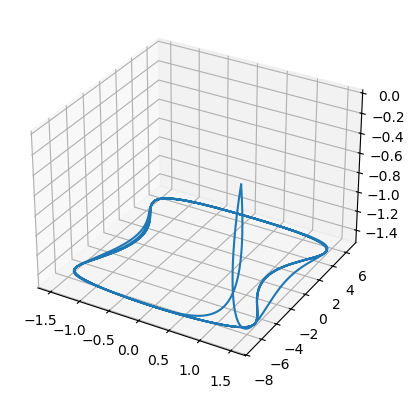

In [39]:
%matplotlib
ax = plt.axes(projection='3d')
ax.plot3D(x__,y__,z__)
plt.show()

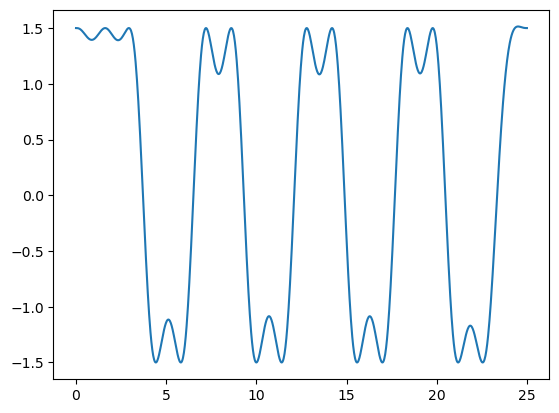

In [40]:
plt.plot(t_,x__)

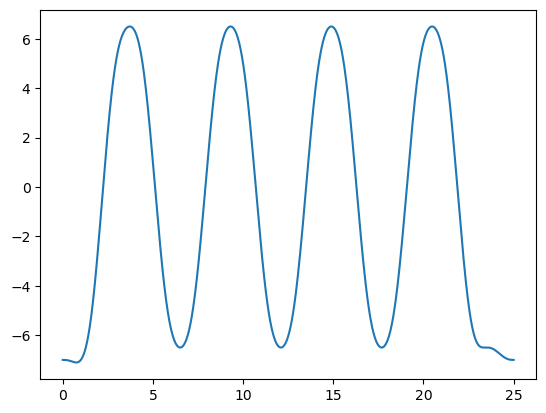

In [41]:
plt.plot(t_, y__)

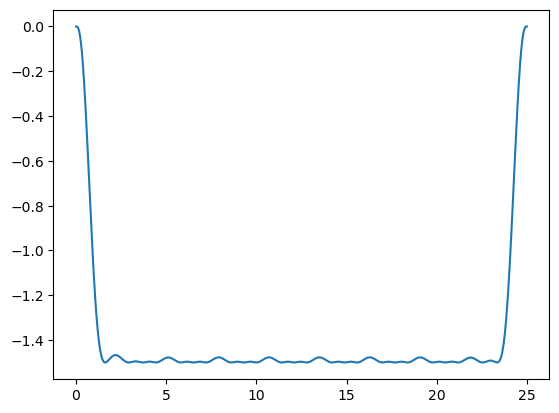

In [42]:
plt.plot(t_, z__)

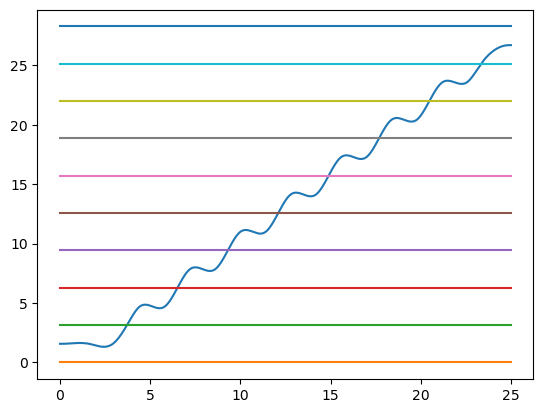

In [45]:
plt.plot(t_, psi__)
for i in range(10):
    plt.plot(t_,np.ones_like(t_)*np.pi*i)